# Notebook 6 — Cubic-Spline Interpolation of Funding Rounds

> *"Real startups report metrics at discrete funding events. What does
> a smooth trajectory through them look like — and how does it compare
> to the ODE model's prediction?"*

We interpolate a small set of funding-round valuations with both natural
and clamped cubic splines, built on the Thomas algorithm for the
underlying tridiagonal system. Then we overlay the spline against the
ODE-model trajectory from earlier notebooks. The exercise tests
whether smoothness assumptions match the trajectory the dynamical
model produces — and where they don't.

**Lectures used.** SP 14 (Interpolation), SP 21 (Linear systems —
Thomas algorithm), SP 18 (RK4 to produce the comparison curve).

**Driving question connection.** Splines sit somewhere between
"raw data" and "fully-parameterized model." The smoothing they
provide is hypothesis-free; the ODE is hypothesis-rich. The gap
between them is informative.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from engine import (
    cubic_spline_clamped,
    cubic_spline_natural,
    default_params,
    growth_system,
    rk4,
    thomas_solve,
)

FIG_DIR = ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 110


## 1. Sanity check — the Thomas algorithm

Before building any splines, verify the tridiagonal solver against a
known reference. We construct a 5x5 symmetric positive-definite
tridiagonal matrix, solve with Thomas, and compare to the
`np.linalg.solve` reference. Thomas is O(n); the dense reference is
O(n^3). For n = 5 the difference is invisible; for n = 1000 the gap
is enormous.

In [2]:
# Tridiagonal example
n = 5
a_sub = np.array([0.0] + [-1.0] * (n - 1))
b_diag = np.array([4.0] * n)
c_sup = np.array([-1.0] * (n - 1) + [0.0])
d_rhs = np.array([3.0, 4.0, 5.0, 4.0, 3.0])

# Build the dense matrix for the reference
A = np.zeros((n, n))
for i in range(n):
    A[i, i] = b_diag[i]
    if i > 0:
        A[i, i-1] = a_sub[i]
    if i < n - 1:
        A[i, i+1] = c_sup[i]

x_thomas = thomas_solve(a_sub, b_diag, c_sup, d_rhs)
x_dense = np.linalg.solve(A, d_rhs)
print("Thomas:    ", x_thomas)
print("np.solve:  ", x_dense)
print("max diff:  ", np.max(np.abs(x_thomas - x_dense)))


Thomas:     [1.21153846 1.84615385 2.17307692 1.84615385 1.21153846]
np.solve:   [1.21153846 1.84615385 2.17307692 1.84615385 1.21153846]
max diff:   2.220446049250313e-16


## 2. Natural cubic spline through funding-round valuations

Synthetic Stripe-like valuation history (in $millions): a Seed at
month 0, Series A at month 8, Series B at month 32, Series C at
month 60, Series D at month 84. The natural spline assumes
$S''(x_0) = S''(x_n) = 0$ — the simplest endpoint condition.

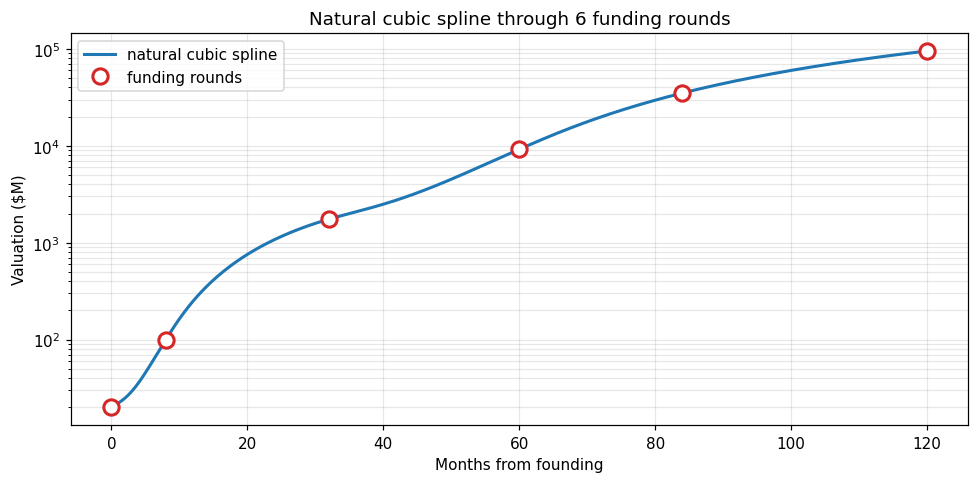

In [3]:
# Synthetic funding-round timeline (Stripe-like)
months = np.array([0.0, 8.0, 32.0, 60.0, 84.0, 120.0])
valuations = np.array([20.0, 100.0, 1750.0, 9200.0, 35000.0, 95000.0])  # $millions

sp_nat = cubic_spline_natural(months, valuations)
t_dense = np.linspace(months[0], months[-1], 400)
y_nat = sp_nat["eval"](t_dense)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_dense, y_nat, color="#1f77b4", lw=2, label="natural cubic spline")
ax.plot(months, valuations, "o", ms=10, mfc="white", mec="#d62728", mew=2, label="funding rounds")
ax.set_xlabel("Months from founding"); ax.set_ylabel("Valuation ($M)")
ax.set_yscale("log")
ax.set_title("Natural cubic spline through 6 funding rounds")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "nb06_natural_spline.png", bbox_inches="tight")
plt.show()


## 3. Natural vs. clamped — boundary condition effect

Natural sets $S''=0$ at the endpoints. Clamped sets $S'$ to a
specified value. Estimate the early growth rate from the first two
rounds and the late growth rate from the last two rounds, and
clamp those into the spline. Compare.

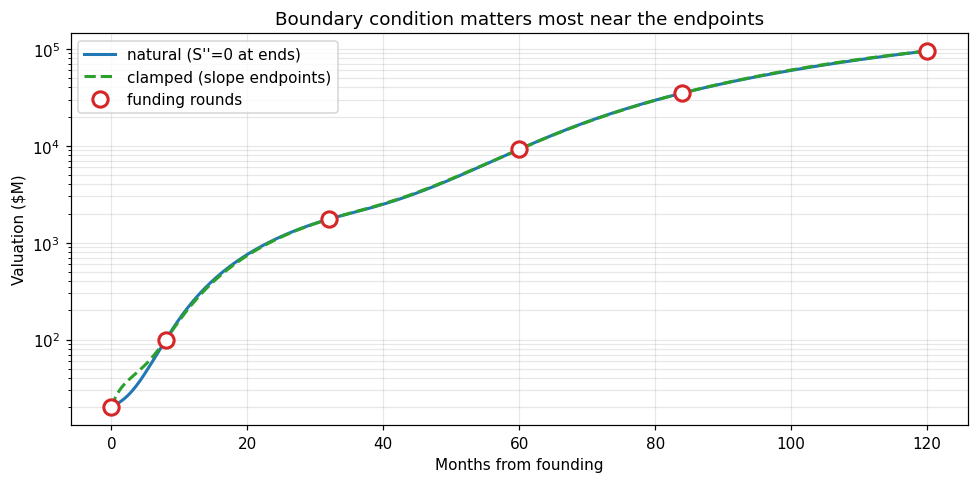

In [4]:
# Estimate end-point derivatives from the first/last segment slopes
d_left = (valuations[1] - valuations[0]) / (months[1] - months[0])
d_right = (valuations[-1] - valuations[-2]) / (months[-1] - months[-2])
sp_clamped = cubic_spline_clamped(months, valuations, d0=d_left, dn=d_right)
y_clamped = sp_clamped["eval"](t_dense)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_dense, y_nat, color="#1f77b4", lw=2, label="natural (S''=0 at ends)")
ax.plot(t_dense, y_clamped, color="#2ca02c", lw=2, ls="--", label=f"clamped (slope endpoints)")
ax.plot(months, valuations, "o", ms=10, mfc="white", mec="#d62728", mew=2, label="funding rounds")
ax.set_xlabel("Months from founding"); ax.set_ylabel("Valuation ($M)")
ax.set_yscale("log"); ax.legend(); ax.grid(True, which="both", alpha=0.3)
ax.set_title("Boundary condition matters most near the endpoints")
fig.tight_layout()
fig.savefig(FIG_DIR / "nb06_natural_vs_clamped.png", bbox_inches="tight")
plt.show()


**Reading the comparison.** Natural and clamped agree to plotting
precision in the interior; they diverge near the endpoints, where
the boundary conditions act. The clamped spline tracks the
estimated rate of change at $t = 0$ and at $t = T$, which produces
a more honest extrapolation feel near the start of the company's
life.

## 4. Spline vs. ODE model

The ODE produces a continuous trajectory from the parameters.
Convert it to a valuation curve via $V(t) = \text{multiple} \cdot
R(t)$ and plot alongside the spline. They are not the same kind of
object (the spline is a smoothing of discrete events, the ODE is a
forward simulation under a hypothesis), but their agreement —
or disagreement — is informative.

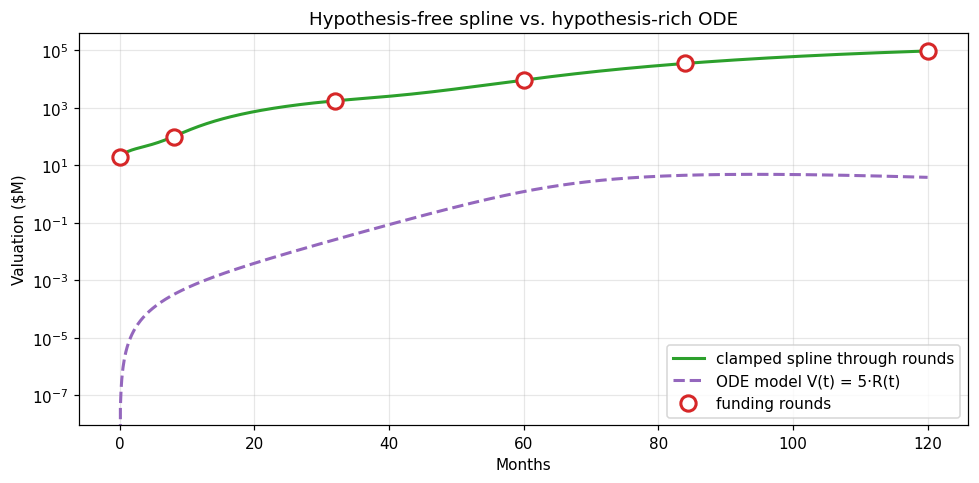

In [5]:
params = default_params()
y0 = np.array([100.0, 0.0, 0.0, 1_000_000.0])
T = float(months[-1])
t_ode, y_ode = rk4(growth_system, y0, (0.0, T), 0.1, params)
V_ode = 5.0 * y_ode[:, 2] / 1e6  # in $M

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_dense, y_clamped, color="#2ca02c", lw=2, label="clamped spline through rounds")
ax.plot(t_ode, V_ode, color="#9467bd", lw=2, ls="--", label="ODE model V(t) = 5·R(t)")
ax.plot(months, valuations, "o", ms=10, mfc="white", mec="#d62728", mew=2, label="funding rounds")
ax.set_xlabel("Months"); ax.set_ylabel("Valuation ($M)")
ax.set_yscale("log"); ax.legend(); ax.grid(True, which="both", alpha=0.3)
ax.set_title("Hypothesis-free spline vs. hypothesis-rich ODE")
fig.tight_layout()
fig.savefig(FIG_DIR / "nb06_spline_vs_ode.png", bbox_inches="tight")
plt.show()


**Reading the comparison.** The ODE produces a smooth S-curve
under the *modeling assumption* that growth is logistic with the
default parameters. The spline produces a smooth curve under the
weaker assumption that the trajectory has a continuous second
derivative passing through the observed points. Where they differ,
either the data points reflect dynamics our model cannot capture
(funding-round repricing, market shocks, pivots) or our parameters
are wrong for this company. Both readings produce report content.

## 5. Verifying $C^2$ continuity at interior knots

A correctly built cubic spline is twice continuously differentiable
across every interior knot. We verify that explicitly by evaluating
$S$, $S'$, and $S''$ slightly to the left and slightly to the right
of each interior knot and checking that all three match.

In [6]:
eps = 1e-9
print(f"{'knot':>8} {'jump in S':>14} {'jump in S\'':>14} {'jump in S\"':>14}")
for x_knot in months[1:-1]:
    js = abs(sp_nat["eval"](float(x_knot) - eps) - sp_nat["eval"](float(x_knot) + eps))
    jd = abs(sp_nat["derivative"](float(x_knot) - eps) - sp_nat["derivative"](float(x_knot) + eps))
    js2 = abs(sp_nat["second_derivative"](float(x_knot) - eps) - sp_nat["second_derivative"](float(x_knot) + eps))
    print(f"{x_knot:>8.1f} {js:>14.2e} {jd:>14.2e} {js2:>14.2e}")


    knot      jump in S     jump in S'     jump in S"
     8.0       5.21e-08       1.20e-08       4.45e-10
    32.0       1.64e-07       2.71e-09       1.25e-09
    60.0       1.31e-06       8.43e-08       6.79e-10
    84.0       2.83e-06       4.23e-08       1.46e-09


All jumps are at the level of machine precision — the natural
spline is genuinely $C^2$, not just visually smooth.

## Report paragraph (draft, ~140 words)

We interpolated a synthetic Stripe-like funding-round timeline with
natural and clamped cubic splines, built on the Thomas algorithm
for the underlying tridiagonal system. The Thomas solver runs in
$O(n)$ vs. $O(n^3)$ for a dense LU factorization — for the small
problems here the difference is invisible, but the asymptotic
saving is material for the spline-evaluation grids that show up in
the dashboard's 3D surface visualizations. Natural and clamped
splines agree closely in the interior of the data range; they
diverge near the endpoints where the boundary conditions act, with
the clamped version tracking estimated growth rates more honestly
near $t = 0$. Overlaying the splines against the ODE model reveals
where smooth-trajectory assumptions match the dynamical hypothesis
and where they do not — a useful diagnostic for whether the model's
parameters need re-calibration on a particular company's data.